Practical 06 - Deep Learning for Computer Vision

Reading: Please read the following notebook
https://colab.research.google.com/github/fchollet/deep-learning-with-python-notebooks/blob/master/chapter08_intro-to-dl-for-computer-vision.ipynb

Task 1: Build your own model

Task 2: Data augmentation and Dropout

Task 3: Fine-tune a pretrained model

Data: CIFAR10, 10 classes


In [ ]:
# Note: If you run this notebook on Google Colab, select runtime T4 GPU!!!

from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# Load CIFAR-10 data
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Preprocess data (normalizing)
train_images = ...
test_images  = ...

# Split the training set into training and validation sets
train_images, val_images, train_labels, val_labels = train_test_split( ...)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [ ]:
# This is the keras/tensorflow framework. Pytorch users please adopt.
# EXERCISE 1
from tensorflow import keras
from tensorflow.keras import layers, models

# Construct a model with 3 conv layers and two max pooling layers in between
# softmax output layer
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(...)
x = layers.MaxPooling2D(...)
x = layers.Conv2D(...)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model using RMSprop optimizer
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
model.fit(train_images, train_labels,
          epochs=5,
          batch_size=64,
          validation_data=(val_images, val_labels))

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")


In [ ]:
# Compile the model using adam optimizer
model.compile(...)

# Train the model - if you do not have a wandb account
model.fit( ...)

# Evaluate the model on test data
test_loss, test_acc =

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


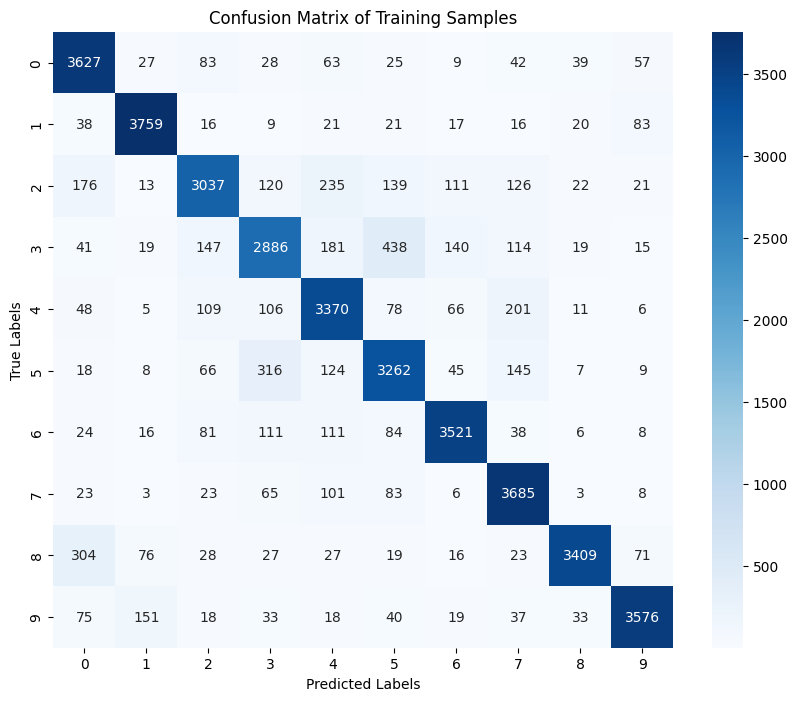

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict the labels of the training images
train_predictions =
train_pred_labels =

# Compute the confusion matrix
cm = confusion_matrix(...)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(...)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix of Training Samples")
plt.show()

In [ ]:
# EXERCISE 2 Data augmentation,dropout and hyper-parameters
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal")
    ]
)

# rebuild the model with augmentation and dropout
inputs = keras.Input(shape=(32, 32, 3))
x = ...

# Compile the model using adam optimizer
model.compile(...)

# Train the model
model.fit(...)

# Evaluate the model on test data
test_loss, test_acc =


In [ ]:
# EXERCISE 3: Fine-tune a pre-trained conv-net
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# Load VGG16 model with pretrained ImageNet weights, excluding the top layers
conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

conv_base.trainable = True
for layer in conv_base.layers[:-1]:
    layer.trainable = False

# rebuild model with pre-trained VGG16
inputs = keras.Input(shape=(32, 32, 3))
x = ...

# Compile the model using adam optimizer
model.compile(...)

# Train the model
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(train_images, train_labels,
          epochs=10,
          batch_size=16,
          validation_data=(val_images, val_labels),
                    callbacks=callbacks)

# Evaluate the model on test data
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(...)


PYTORCH APPROACH
This approach requires more coding and hence is more suitable to experienced learners.

See some online tutorials/examples

https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

https://blog.paperspace.com/writing-cnns-from-scratch-in-pytorch/


In [ ]:
# APPROACH 2: PYTORCH

import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# Define transformations: normalize images to range [0, 1] and convert to tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize with mean and std
])

# Load CIFAR-10 data
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Extract train images and labels
train_images = train_dataset.data
train_labels = train_dataset.targets

# Split train set into training and validation sets using sklearn
train_indices, val_indices = train_test_split(
    range(len(train_images)), test_size=0.2, stratify=train_labels, random_state=42)

# Subset the train_dataset to create train and validation sets
train_subset = Subset(train_dataset, train_indices)
val_subset   = Subset(train_dataset, val_indices)

# Create DataLoader objects for training, validation, and testing
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
# Exercise 1: Basic conv net
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F

# Define the neural network model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # 3 convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(...)
        self.conv3 = nn.Conv2d(...)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 8 * 8, 10)  # 128 feature maps of 8x8 each

    def forward(self, x):
        # Apply convolutional layers and pooling
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # complete your code below


        # Flatten the output
        x = x.view(-1, 128 * 8 * 8)

        # Fully connected output layer with softmax
        x = F.softmax(self.fc1(x), dim=1)
        return x

# Initialize the model
model = CNNModel()

# Define the optimizer and loss function
optimizer =
criterion =

# Check if a GPU is available and move the model to GPU if so
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training function
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients


            # Forward pass


            # Backward pass and optimize




        print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")

        # Validate the model after each epoch


# Validation function
def validate_model(model, val_loader):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():  # Turn off gradients for validation
        for inputs, labels in val_loader:


    print(f"Validation Accuracy: {100 * correct / total:.2f}%")

# Train the model
train_model(model, train_loader, val_loader, epochs=5)

# Evaluate the model on test data
model.eval()  # Set model to evaluation mode
correct = 0
total = 0
with torch.no_grad():  # Turn off gradients for testing
    for inputs, labels in test_loader:


print(f"Test Accuracy: {100 * correct / total:.2f}%")


In [ ]:
# EXERCISE 2 - DATA AUGMENTATION AND DROPOUT
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define the data augmentation using transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Random horizontal flip
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1] range
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1] range
])

# Load the datasets with the new transforms (train has augmentation, test does not)
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create DataLoader objects for the training, validation, and test sets
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)


In [ ]:
# EXERCISE 3 - Fine-tuning a Pre-trained model
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import transforms
import copy

# Load VGG16 with pretrained ImageNet weights, excluding the top layers
vgg16 = models.vgg16(pretrained=True)

# Freeze all the layers except the last layer
for param in vgg16.parameters():
    param.requires_grad = False

# Unfreeze only the last convolutional block (you can adjust this to fine-tune different parts)
for param in vgg16.features[-1].parameters():
    param.requires_grad = True

# Modify the classifier to fit the CIFAR-10 dataset (10 classes)

# Move the model to the GPU if available

# Define optimizer and loss function

# Training function
def train_model(model, train_loader, val_loader, epochs=10):

    avg_loss = running_loss / len(val_loader)
    print(f"Validation Loss: {avg_loss:.4f}")
    return avg_loss

# Test function
def test_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0


    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Assuming DataLoader objects: train_loader, val_loader, test_loader
# Callbacks: Save the best model (fine-tuning)
train_model(vgg16, train_loader, val_loader, epochs=10)

# Test the best model on test data
test_model(vgg16, test_loader)
